<a href="https://colab.research.google.com/github/Ali-B-Indahouse/How-Much-Is-The-real-estate-in-Moscow/blob/main/08_04_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Фаза 2 • Неделя 8 • Четверг
## Нейронные сети
### 🔥 PyTorch: fine tuning

### Подготовка к работе

1. Загрузи этот ноутбук на Google Colab
2. Подгрузи архив [датасета](https://www.kaggle.com/datasets/ikobzev/architectural-heritage-elements-image64-dataset) в свое пространство и разархивируй его с помощью `unzip`.

In [32]:
import torch.nn as nn

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ikobzev/architectural-heritage-elements-image64-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'architectural-heritage-elements-image64-dataset' dataset.
Path to dataset files: /kaggle/input/architectural-heritage-elements-image64-dataset


In [6]:
!unzip /kaggle/input/architectural-heritage-elements-image64-dataset -d /content/sample_data


unzip:  cannot find or open /kaggle/input/architectural-heritage-elements-image64-dataset, /kaggle/input/architectural-heritage-elements-image64-dataset.zip or /kaggle/input/architectural-heritage-elements-image64-dataset.ZIP.


In [26]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(DEVICE)

cuda


1. Убедись, что структура папок соответствует задаче классификации (либо приведите ее к формату, указанному ниже):

        `train`
        
            - class_1
            - class_2
            - ...
            - class_n
            
        `valid`

            - class_1
            - class_2
            - ...
            - class_n

In [ ]:
# code

2. Создай `DataLoader` в для обучающей и валидационных выборок. Примените аугментации к изображениям.

In [18]:
train_dataset.class_to_idx

{'altar': 0,
 'apse': 1,
 'bell_tower': 2,
 'column': 3,
 'dome(inner)': 4,
 'dome(outer)': 5,
 'flying_buttress': 6,
 'gargoyle': 7,
 'stained_glass': 8,
 'vault': 9}

In [22]:
from torch.utils.data import DataLoader
import torchvision

train_dataset = torchvision.datasets.ImageFolder('../kaggle/input/architectural-heritage-elements-image64-dataset/train', transform=preprocess)
test_dataset = torchvision.datasets.ImageFolder('../kaggle/input/architectural-heritage-elements-image64-dataset/test', transform=preprocess)


In [23]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

3. Создай экземпляр предобученной модели: [torchvision models](https://pytorch.org/vision/stable/models.html). Можно взять любую модель для baseline, а дальше попробовать что-то более сложное.

In [124]:
from torchvision.models import regnet_y_1_6gf, RegNet_Y_1_6GF_Weights
weights = RegNet_Y_1_6GF_Weights.IMAGENET1K_V2
preprocess = weights.transforms()
print(preprocess)
model = regnet_y_1_6gf(weights=weights).to(DEVICE)

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [28]:
model

RegNet(
  (stem): SimpleStemIN(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (trunk_output): Sequential(
    (block1): AnyStage(
      (block1-0): ResBottleneckBlock(
        (proj): Conv2dNormActivation(
          (0): Conv2d(32, 48, kernel_size=(1, 1), stride=(2, 2), bias=False)
          (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (f): BottleneckTransform(
          (a): Conv2dNormActivation(
            (0): Conv2d(32, 48, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (b): Conv2dNormActivation(
            (0): Conv2d(48, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=2, bias=False)
            

5. Замени выходной слой форматом, который подходит под задачу: бинарная или многоклассовая классификация.

In [30]:
model.fc

Linear(in_features=888, out_features=1000, bias=True)

In [43]:
model.fc = nn.Linear(in_features=888, out_features=10, bias=True)

In [36]:
model.fc

Linear(in_features=888, out_features=10, bias=True)

In [37]:
for param in model.parameters():
  print(param.requires_grad)

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


In [ ]:
for param in model.parameters():
  print(param.requires_grad)

In [46]:
for param in model.parameters():
  param.requires_grad = False

In [47]:
model.fc.weight.requires_grad = True
model.fc.bias.requires_grad = True

In [48]:
for param in model.parameters():
  print(param.requires_grad)

False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
Fals

In [63]:
import torch
# Пересоздаем оптимизатор после замены слоя и заморозки,
# чтобы он обучал только размороженные параметры (model.fc)
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()

6. Обучи модель (только последний слой!) и зафиксируй метрику на валидационной части выборки.

In [88]:
import numpy as np

def fit(
        model: torch.nn.Module,
        epochs: int,
        optimizer: torch.optim.Optimizer,
        train_loader: DataLoader,
        valid_loader: DataLoader
        ) -> tuple[list, ...]:

  train_epoch_acc = []
  train_epoch_losses = []
  valid_epoch_losses = []
  valid_epoch_acc =[]
  for epoch in range(epochs):
      model.train()
      loss_batch = []
      acc_batch  = []

      for images, labels in train_loader:
          images = images.to(DEVICE)
          labels = labels.to(DEVICE)

          preds = model(images).squeeze(-1)
          loss = criterion(preds, labels.long())
          loss_batch.append(loss.item())

          # поправлена асс для мультклассовой классификации
          predicted_classes = preds.argmax(dim=1)
          accuracy = (predicted_classes == labels).float().mean().item()
          acc_batch.append(accuracy)

          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

      train_epoch_losses.append(np.mean(loss_batch))
      train_epoch_acc.append(np.mean(acc_batch))

      model.eval()
      loss_batch = []
      acc_batch  = []
      for images, labels in valid_loader:
          images = images.to(DEVICE)
          labels = labels.to(DEVICE)
          with torch.no_grad():
              preds = model(images).squeeze(-1)

          loss = criterion(preds, labels.long())
          loss_batch.append(loss.item())

          # поправлена асс для мультклассовой классификации
          predicted_classes = preds.argmax(dim=1)
          accuracy = (predicted_classes == labels).float().mean().item()
          acc_batch.append(accuracy)

      valid_epoch_losses.append(np.mean(loss_batch))
      valid_epoch_acc.append(np.mean(acc_batch))

      print(f'Epoch: {epoch}  loss_train: {train_epoch_losses[-1]:.3f}, loss_valid: {valid_epoch_losses[-1]:.3f}')
      print(f'\t  metrics_train: {train_epoch_acc[-1]:.3f}, metrics_valid: {valid_epoch_acc[-1]:.3f}')
  return train_epoch_losses, valid_epoch_losses, train_epoch_acc, valid_epoch_acc

In [65]:
train_loss, valid_loss, train_metric, valid_metric = fit(
     epochs=10,
     model=model,
     optimizer=optimizer,
     train_loader=train_loader,
     valid_loader=valid_loader
 )

Epoch: 0  loss_train: 0.540, loss_valid: 0.442
	  metrics_train: 0.847, metrics_valid: 0.853
Epoch: 1  loss_train: 0.206, loss_valid: 0.313
	  metrics_train: 0.934, metrics_valid: 0.906
Epoch: 2  loss_train: 0.137, loss_valid: 0.292
	  metrics_train: 0.954, metrics_valid: 0.909
Epoch: 3  loss_train: 0.108, loss_valid: 0.196
	  metrics_train: 0.964, metrics_valid: 0.935
Epoch: 4  loss_train: 0.100, loss_valid: 0.419
	  metrics_train: 0.967, metrics_valid: 0.895
Epoch: 5  loss_train: 0.081, loss_valid: 0.287
	  metrics_train: 0.974, metrics_valid: 0.920
Epoch: 6  loss_train: 0.084, loss_valid: 0.302
	  metrics_train: 0.970, metrics_valid: 0.897
Epoch: 7  loss_train: 0.074, loss_valid: 0.332
	  metrics_train: 0.975, metrics_valid: 0.899
Epoch: 8  loss_train: 0.059, loss_valid: 0.296
	  metrics_train: 0.979, metrics_valid: 0.919
Epoch: 9  loss_train: 0.059, loss_valid: 0.312
	  metrics_train: 0.981, metrics_valid: 0.918


In [69]:
def plot_learning_curves(tl, vl, tm, vm):
    _, ax = plt.subplots(1, 2, figsize=(14, 5))

    # График Loss
    ax[0].plot(tl, label='Train Loss')
    ax[0].plot(vl, label='Valid Loss')
    ax[0].set_title('Cross Entropy Loss')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Loss')
    ax[0].legend()
    ax[0].grid(True)

    # График Accuracy
    # Умножаем на 100, чтобы видеть проценты
    ax[1].plot([x * 100 for x in tm], label='Train Accuracy')
    ax[1].plot([x * 100 for x in vm], label='Valid Accuracy')
    ax[1].set_title('Accuracy (%)')
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('Percentage')
    ax[1].set_ylim(0, 105) # Ограничим шкалу до 100%
    ax[1].legend()
    ax[1].grid(True)

    plt.show()

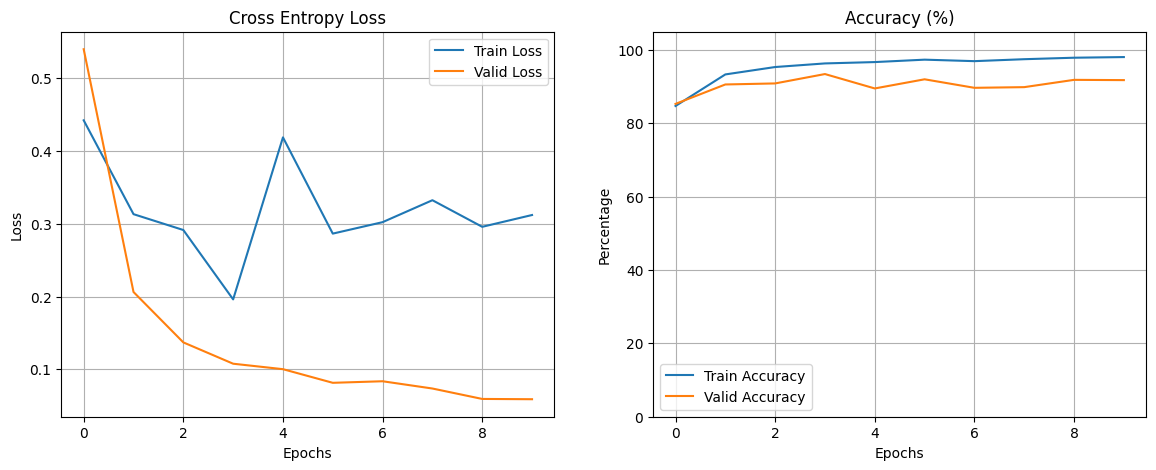

In [89]:
plot_learning_curves(train_metric, valid_loss, train_loss, valid_metric)

7. Распечатай изображение из тестовой выборки и подпиши класс картинки, предсказанный моделью.

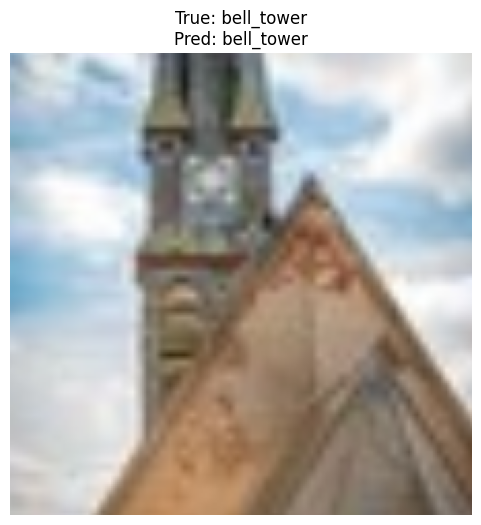

In [68]:
import matplotlib.pyplot as plt

# Получаем один батч из валидационного лоадера
images, labels = next(iter(valid_loader))

# Инвертируем словарь классов, чтобы получить названия по индексам
idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}

model.eval()
with torch.no_grad():
    outputs = model(images.to(DEVICE))
    _, predicted = torch.max(outputs, 1)

# Визуализируем первое изображение из батча
img = images[0].permute(1, 2, 0).cpu().numpy()
# Денормализация (приблизительная для визуализации)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img = std * img + mean
img = np.clip(img, 0, 1)

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"True: {idx_to_class[labels[0].item()]}\nPred: {idx_to_class[predicted[0].item()]}")
plt.axis('off')
plt.show()

8. "Разморозь" несоклько слоев базовой модели и вновь обучи ее. Зафиксируй метрику качества для модели. О том, как сделать unfreeze нескольких слоев сразу, а не только последнего, можно почитать тут: [discuss.pytorch.org](https://discuss.pytorch.org/t/how-the-pytorch-freeze-network-in-some-layers-only-the-rest-of-the-training/7088/3)

In [80]:
for i, child in enumerate(model.children()):
    print(f"Layer {i}: {child.__class__.__name__}")

Layer 0: SimpleStemIN
Layer 1: Sequential
Layer 2: AdaptiveAvgPool2d
Layer 3: Linear


In [125]:
for param in model.parameters():
    param.requires_grad = False

# 2. Размораживаем финальный слой (вы уже это сделали, но закрепим)
for param in model.fc.parameters():
    param.requires_grad = True

# 3. Размораживаем последний сверточный блок (Stage 4)
# В RegNet это последний элемент в trunk_output
for param in model.trunk_output[-1].parameters():
    param.requires_grad = True


In [126]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"Разморожен слой: {name}")

Разморожен слой: trunk_output.block4.block4-0.proj.0.weight
Разморожен слой: trunk_output.block4.block4-0.proj.1.weight
Разморожен слой: trunk_output.block4.block4-0.proj.1.bias
Разморожен слой: trunk_output.block4.block4-0.f.a.0.weight
Разморожен слой: trunk_output.block4.block4-0.f.a.1.weight
Разморожен слой: trunk_output.block4.block4-0.f.a.1.bias
Разморожен слой: trunk_output.block4.block4-0.f.b.0.weight
Разморожен слой: trunk_output.block4.block4-0.f.b.1.weight
Разморожен слой: trunk_output.block4.block4-0.f.b.1.bias
Разморожен слой: trunk_output.block4.block4-0.f.se.fc1.weight
Разморожен слой: trunk_output.block4.block4-0.f.se.fc1.bias
Разморожен слой: trunk_output.block4.block4-0.f.se.fc2.weight
Разморожен слой: trunk_output.block4.block4-0.f.se.fc2.bias
Разморожен слой: trunk_output.block4.block4-0.f.c.0.weight
Разморожен слой: trunk_output.block4.block4-0.f.c.1.weight
Разморожен слой: trunk_output.block4.block4-0.f.c.1.bias
Разморожен слой: trunk_output.block4.block4-1.f.a.0.w

In [127]:
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0001, weight_decay=0.01)
criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.1)

In [128]:
ft_train_loss, ft_valid_loss, ft_train_metric, ft_valid_metric = fit(
     epochs=10,
     model=model,
     optimizer=optimizer,
     train_loader=train_loader,
     valid_loader=valid_loader
 )

Epoch: 0  loss_train: 2.395, loss_valid: 1.436
	  metrics_train: 0.681, metrics_valid: 0.894
Epoch: 1  loss_train: 1.331, loss_valid: 1.311
	  metrics_train: 0.919, metrics_valid: 0.920
Epoch: 2  loss_train: 1.224, loss_valid: 1.280
	  metrics_train: 0.952, metrics_valid: 0.934
Epoch: 3  loss_train: 1.169, loss_valid: 1.268
	  metrics_train: 0.968, metrics_valid: 0.932
Epoch: 4  loss_train: 1.133, loss_valid: 1.253
	  metrics_train: 0.980, metrics_valid: 0.935
Epoch: 5  loss_train: 1.112, loss_valid: 1.229
	  metrics_train: 0.987, metrics_valid: 0.940
Epoch: 6  loss_train: 1.092, loss_valid: 1.241
	  metrics_train: 0.992, metrics_valid: 0.939
Epoch: 7  loss_train: 1.085, loss_valid: 1.226
	  metrics_train: 0.993, metrics_valid: 0.940
Epoch: 8  loss_train: 1.077, loss_valid: 1.219
	  metrics_train: 0.995, metrics_valid: 0.945
Epoch: 9  loss_train: 1.070, loss_valid: 1.217
	  metrics_train: 0.996, metrics_valid: 0.943


9. Сравни качество двух моделей: предобученной с замененным выходным слоем и дообученной с несколькими размороженными слоями.

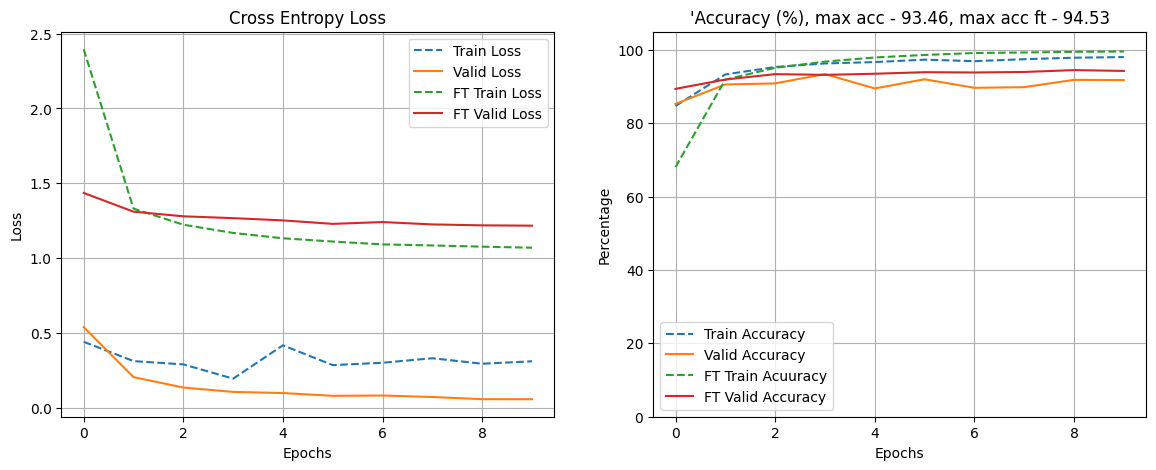

In [129]:
_, ax = plt.subplots(1, 2, figsize=(14, 5))

# График Loss
ax[0].plot(train_metric, label='Train Loss', linestyle='--')
ax[0].plot(valid_loss, label='Valid Loss')
ax[0].plot(ft_train_loss, label='FT Train Loss', linestyle='--')
ax[0].plot(ft_valid_loss, label='FT Valid Loss')
ax[0].set_title('Cross Entropy Loss')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[0].grid(True)

# График Accuracy
# Умножаем на 100, чтобы видеть проценты
ax[1].plot([x * 100 for x in train_loss], label='Train Accuracy', linestyle='--')
ax[1].plot([x * 100 for x in valid_metric], label='Valid Accuracy')
ax[1].plot([x * 100 for x in ft_train_metric], label='FT Train Acuuracy', linestyle='--')
ax[1].plot([x * 100 for x in ft_valid_metric], label='FT Valid Accuracy')
ax[1].set_title(f"'Accuracy (%), max acc - {max(valid_metric)*100:.2f}, max acc ft - {max(ft_valid_metric)*100:.2f}")
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Percentage')
ax[1].set_ylim(0, 105) # Ограничим шкалу до 100%
ax[1].legend()
ax[1].grid(True)

plt.show()


<img src="https://icons.iconarchive.com/icons/icons8/windows-8/256/Programming-Github-icon.png" width=32 /> Сохрани файл для __github__ и распечатай результат команды `!git status` в ячейке ниже.

In [134]:
!git add .
!git commit -m "Completed model fine-tuning and evaluation"
!git status

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git


10. Сохрани модель (пример можно посмотреть [тут](../../learning/aux/model_saving.ipynb) или в [документации](https://pytorch.org/tutorials/beginner/saving_loading_models.html))

In [ ]:
# code

11. Реализуй функцию, которая на вход принимает путь к файлу, а в ответ возвращает класс объекта.

In [132]:

import requests
from io import BytesIO
from PIL import Image

def get_prediction(path: str) -> str:
  if path.startswith('http'):
        response = requests.get(path)
        img = Image.open(BytesIO(response.content)).convert('RGB')
  else:
        img = Image.open(path).convert('RGB')

  tensor= preprocess(img).unsqueeze(0).to(DEVICE)

  model.eval()
  with torch.no_grad():
    output = model(tensor)
    pred = output.argmax().item()

  class_name = idx_to_class.get(pred, 'Unknown')

  return class_name


In [133]:
get_prediction('https://www.facade-project.ru/images/cms/data/gotika/1-1-gotica.jpg')

'flying_buttress'

12. Сохрани ноутбук на github